In [16]:
# importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#Reading all sheet at once
sheets=pd.read_excel("C:\\Users\\asus\\Desktop\\Python\\Projects\\Sales_Data_analysis\\data\\Regional Sales Dataset.xlsx",sheet_name=None)


In [18]:
# assign df to each sheet
df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_regions=sheets['Regions']
df_state_reg=sheets['State Regions']
df_products=sheets['Products']

In [19]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [20]:
df_sales.shape

(64104, 12)

In [21]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [22]:
df_customers.shape

(175, 2)

In [23]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [24]:
df_regions.shape

(994, 15)

In [25]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [26]:
# set the first row of a DataFrame as column headers
new_header=df_state_reg.iloc[0]
df_state_reg.columns=new_header
df_state_reg=df_state_reg[1:].reset_index(drop=True)

df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [27]:
df_state_reg.shape

(48, 3)

In [28]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [29]:
df_products.shape

(30, 2)

In [30]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [31]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [32]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [33]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

### Cleaning 


In [34]:
## merging sales with customers 
df=df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [35]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [36]:
# now merging wiht products
df=df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [37]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [38]:
# now merging wiht regions
df=df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)


In [39]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [40]:
# merging with state_region
df=df.merge(
    df_state_reg[['State Code','Region']],
    how='left',
    left_on='state_code',
    right_on='State Code'
)


In [41]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,-74.82877,445,51326,18095,69878,26311722,253129,America/New York,PA,Northeast
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,-88.03424,847,69308,26242,71573,35271964,370235,America/Chicago,IL,Midwest
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,-80.20644,954,57234,20651,42786,22943340,594611,America/New York,FL,South
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,-78.74182,716,87514,38912,48662,76228647,162756,America/New York,NY,Northeast


In [42]:
# drop the duplicate cols
cols=['Customer Index','Index','id','State Code']
df=df.drop(columns=cols,errors='ignore')

In [43]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,40.15511,-74.82877,445,51326,18095,69878,26311722,253129,America/New York,Northeast
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,42.11030,-88.03424,847,69308,26242,71573,35271964,370235,America/Chicago,Midwest
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,26.24453,-80.20644,954,57234,20651,42786,22943340,594611,America/New York,South
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,42.91002,-78.74182,716,87514,38912,48662,76228647,162756,America/New York,Northeast


In [44]:
# converting all columnaes into lower case for consistency & easier access--
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df.columns

Index(['ordernumber', 'orderdate', 'customer_name_index', 'channel',
       'currency_code', 'warehouse_code', 'delivery_region_index',
       'product_description_index', 'order_quantity', 'unit_price',
       'line_total', 'total_unit_cost', 'customer_names', 'product_name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'region'],
      dtype='object')

In [45]:
df.to_csv("merged_file.csv")

In [46]:
# keep the important column & delete the col we don't need

cols_to_keep=[
    'ordernumber',
    'orderdate',
    'customer_names',
    'channel',
    'product_name',
    'order_quantity', 
    'unit_price',
    'line_total', 
    'total_unit_cost', 
    'state_code', 
    'county', 
    'state',  
    'region',
    'longitude',
    'latitude',
]

In [47]:
df=df[cols_to_keep]
df.head()

,ordernumber,orderdate,customer_names,channel,product_name,order_quantity,unit_price,line_total,total_unit_cost,state_code,county,state,region,longitude,latitude
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,-81.09983,32.08354
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,-86.10665,39.61366
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,-121.87468,37.66243
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,-86.52639,39.16533
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,-72.52443,41.77524


In [ ]:
# renaming some cols

df=df.rename(columns={
    'ordernumber':'order_number',
    'orderdate':'order_date',
    'line_total':'revenue',
    'longitude':'lon',
    'latitude':'lat'
}
)

df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state,region,lon,lat
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,-81.09983,32.08354
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,-86.10665,39.61366
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,-121.87468,37.66243
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,-86.52639,39.16533
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,-72.52443,41.77524


### Feature Engineering

In [49]:
# adding new cols
df['total_cost']=df['order_quantity']*df['total_unit_cost']
df['profit']=df['revenue']-df['total_cost']

df['profit_margin_pct']=(df['profit']/df['revenue'])*100

# Extract full month name from order_date for labeling (e.g., 'January', 'February')
df['order_month_name'] = df['order_date'].dt.month_name()

# Extract month number from order_date for correct sorting (1–12)
df['order_month_num'] = df['order_date'].dt.month

df.head()



,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state,region,lon,lat,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,-81.09983,32.08354,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,-86.10665,39.61366,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,-121.87468,37.66243,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,-86.52639,39.16533,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,-72.52443,41.77524,10082.160,8249.040,45.0,January,1


### EDA

### 1.Monthly sales trend over time

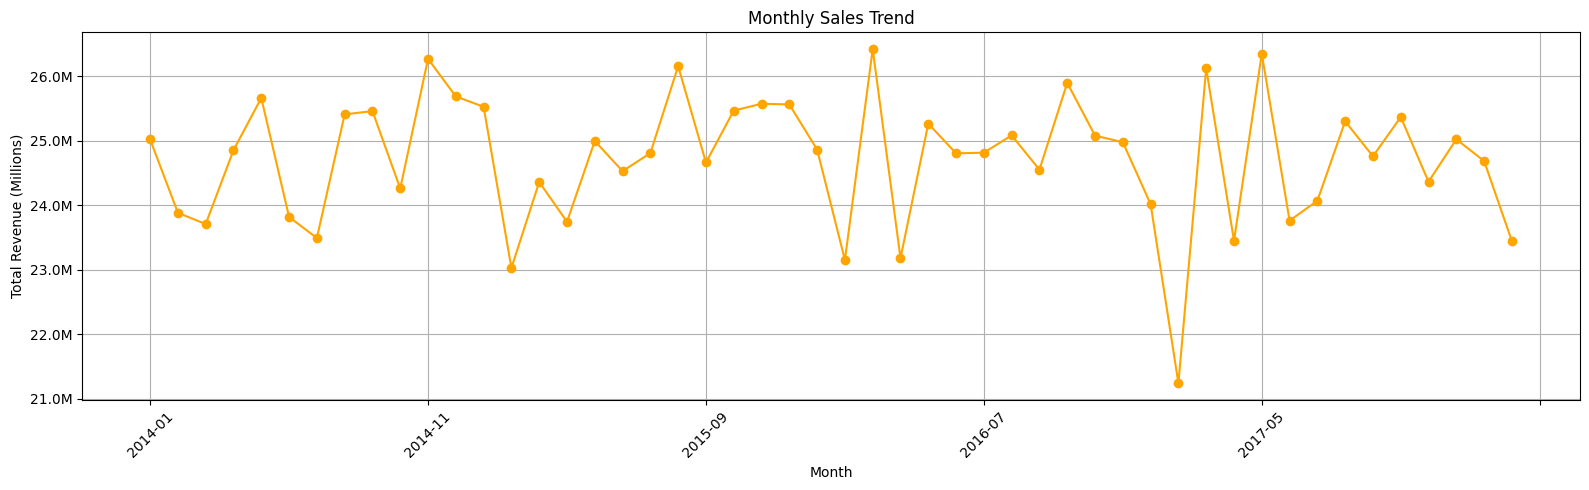

In [50]:
# Extract year & month for grouping(e.g., 2022-01, 2022-02)
df['year_month'] = df['order_date'].dt.to_period('M')

# converting into str as sql server via pyodbc can't understand 'period' type of pandas
df['year_month']=df['year_month'].astype(str)

#calculate total revenue for each month
monthly_sales=df.groupby('year_month')['revenue'].sum()

#create the line chart
plt.figure(figsize=(16,5))

# Plot the monthly sales trend with circle markers and navy line
monthly_sales.plot(marker='o', color='orange')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

#add title & axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Insights

Sales consistently cycle between 24 and 26 M, with clear peaks in late spring to early summer (May–June) and troughs each January.

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.

However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.

### 2.Monthly Sales Trend (All year Combined)

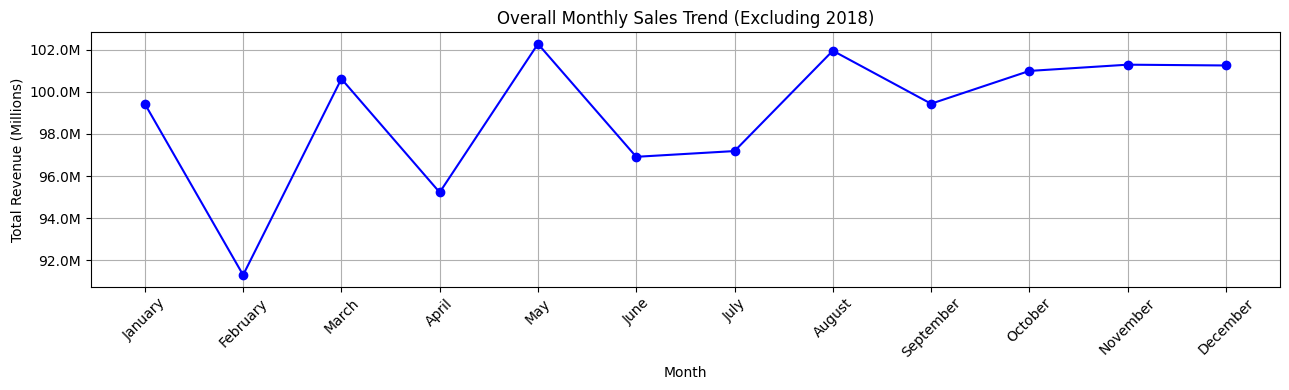

In [51]:
#Filter out any 2018 orders
df_new=df[df['order_date'].dt.year!=2018]

monthly_sales=df_new.groupby(
    ['order_month_num','order_month_name'])['revenue'].sum().reset_index().sort_values('order_month_num')

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales['order_month_name'], 
    monthly_sales['revenue'],                   # Y-axis: total revenue
    marker='o',                                # circle markers
    color='blue'                               # line color
)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

#add title & axis labels
plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


#### Insights

Across all years, January begins strong with roughly 99M, folllowing by steep decline thorugh april's slowpoint(~95M).

Sales rebound in May & Augus(~102M) before settling into a plateuo of 99–101 M from September to December.

This pattern reveals a strong post–New Year surge, a spring dip, and a mid–summer bump each calendar year.

#### 3.Top 10 Products by Revenue (in Millions)

C:\Users\asus\AppData\Local\Temp\ipykernel_11316\2929310198.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


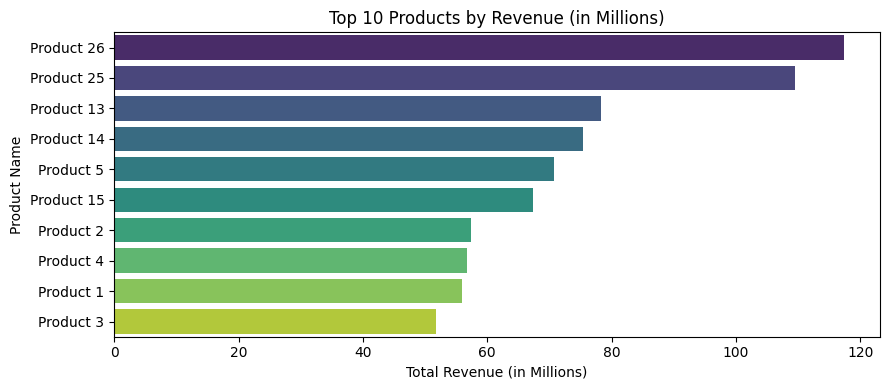

In [52]:

# Calculate total revenue for each product and convert values to millions
top_prod = df.groupby('product_name')['revenue'].sum()/1_000_000 

# Select the top 10 products by revenue
top_prod = top_prod.nlargest(10)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_prod.values,    # X-axis: revenue values in millions
    y=top_prod.index,     # Y-axis: product names
    palette='viridis'     # Color palette for bars
)
# Add title and axis labels
plt.title('Top 10 Products by Revenue (in Millions)')  
plt.xlabel('Total Revenue (in Millions)')              
plt.ylabel('Product Name')                             
plt.tight_layout()
plt.show()

### Insights

Products 26 and 25 pull away at 118M and 110M, with a sharo drop to 78M for Product 13 and tight mid-pack at 68–75 M.

The bottom four cluster at 52–57 M, highlighting similar constraints.

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.

### 4. Top 10 Products by Avg Profit Margin

C:\Users\asus\AppData\Local\Temp\ipykernel_11316\3031969015.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


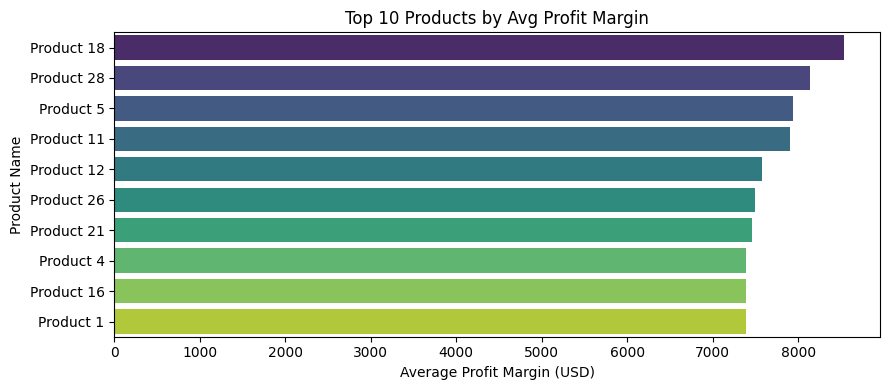

In [53]:
# 1️⃣ Compute average profit per product and take the top 10
top_margin = (
    df.groupby('product_name')['profit']
      .mean()                        # Calculate mean profit for each product
      .sort_values(ascending=False)  # Sort from highest to lowest average profit
      .head(10)                      # Keep only the top 10 products
)

plt.figure(figsize=(9, 4))

#Plotting a horizontal bar chart
sns.barplot(
    x=top_margin.values,    # X-axis: average profit values
    y=top_margin.index,     # Y-axis: product names
    palette='viridis'       # Color palette for the bars
)

# Adding title and axis labels
plt.title('Top 10 Products by Avg Profit Margin')  
plt.xlabel('Average Profit Margin (USD)')          
plt.ylabel('Product Name')                         
plt.tight_layout()
plt.show()
     

#### Insights

Products 18 and 28 lead with average profit margins of approximately 8.0-8.3K followedclosely by Product 5 & Product 11 around 7.9-8.0K

Mid-tier performers like Products 12, 26, and 21 cluster in the 7.4–7.6 K range while the bottom tier(Product 4 ,16 and 1) fall between 7.4-7.6K.

Focusing on margin optimization strategies from top performers may help elevate overall product profitability.


### 5.Sales by Channel

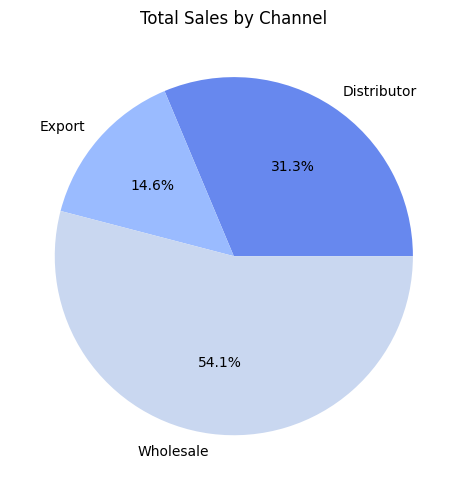

In [54]:
chan_sales=df.groupby('channel')['revenue'].sum()

plt.figure(figsize=(16,5))

plt.pie(
    chan_sales.values,                   # Data: revenue values per channel
    labels=chan_sales.index,             # Labels: channel names
    autopct='%1.1f%%',                   # Display percentages with one decimal                      # Rotate chart so first slice starts at 140 degrees
    colors=sns.color_palette('coolwarm') # Color palette for slices
)
plt.title('Total Sales by Channel')
plt.tight_layout()
plt.show()


#### Insights

Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.


### 6.Average Order Value (AOV) Distribution

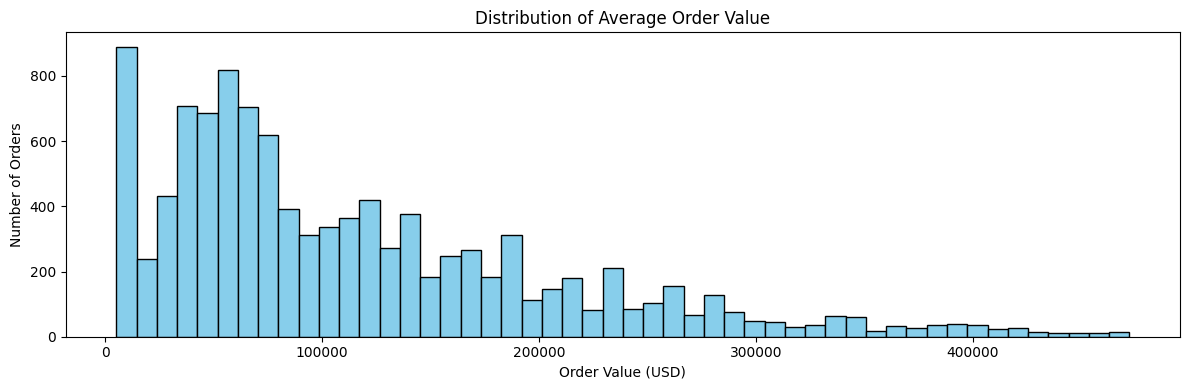

In [55]:
# Calculate the total revenue for each order to get the order value
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12, 4))

plt.hist(
    aov,               # Data: list of order values
    bins=50,           # Number of bins to group order values
    color='skyblue',   # Fill color of the bars
    edgecolor='black'  # Outline color of the bars
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### 7. Region Wise Sales

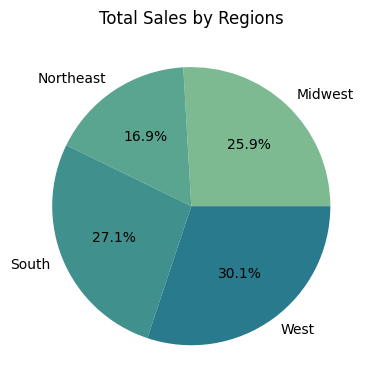

In [56]:
reg_sale=df.groupby('region')['revenue'].sum().reset_index()
reg_sale

plt.figure(figsize=(12,4))

plt.pie(reg_sale['revenue'],
    labels=reg_sale['region'],
    autopct='%1.1f%%',
    colors=sns.color_palette('crest'))

plt.title('Total Sales by Regions')
plt.tight_layout()
plt.show()


#### Insights
West dominates with 30.1% of sales, underscoring its market leadership.

South & Midwest each contribute around 27.1% & 25.9% , indicating strong, consistent demand across central regions.

Northeast trails at about 16.9% signaling room for growth and targeted investment.

Action: Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.

### 8.Top 10 States by Revenue & Order count

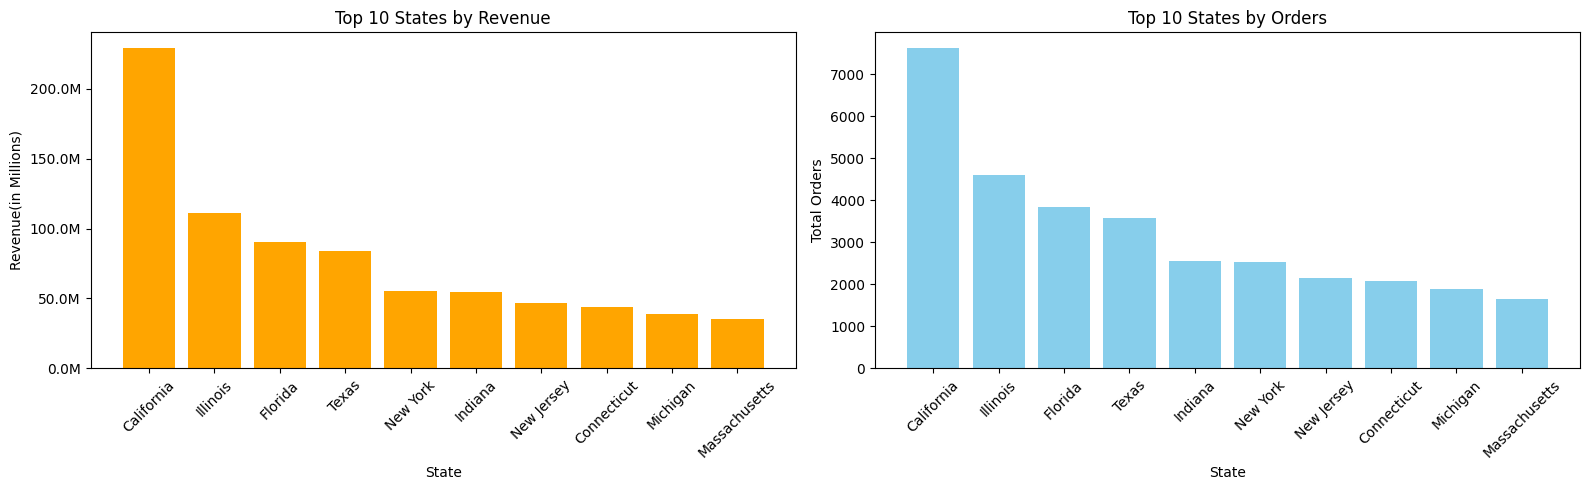

In [57]:
top_state_rev=df.groupby('state')['revenue'].sum().reset_index().sort_values('revenue',ascending=False).head(10)

top_state_order=df.groupby('state')['order_number'].nunique().reset_index().sort_values('order_number',ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Chart 1 → Top States by Revenue
axes[0].bar(top_state_rev['state'], top_state_rev['revenue'], color='orange')
axes[0].set_title('Top 10 States by Revenue')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Revenue(in Millions)')

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
axes[0].yaxis.set_major_formatter(formatter)

axes[0].tick_params(axis='x', rotation=45)

# Chart 2 → Top States by Orders
axes[1].bar(top_state_order['state'], top_state_order['order_number'], color='skyblue')
axes[1].set_title('Top 10 States by Orders')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Total Orders')

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Insights

Top revenue is generated by California of around ~250M & also placing most orders of ~12000. 

### 9.Average Profit Margin by channel


C:\Users\asus\AppData\Local\Temp\ipykernel_11316\489899236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


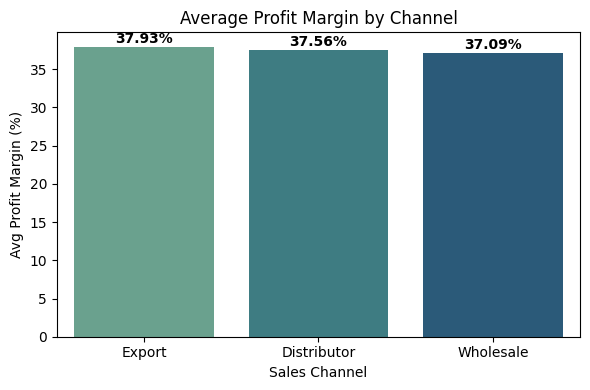

In [58]:
#Compute average profit margin percentage for each channel
channel_margin = (
    df.groupby('channel')['profit_margin_pct']  
      .mean()                                  
      .sort_values(ascending=False)            
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=channel_margin.index,    
    y=channel_margin.values,   
    palette='crest'        
)
plt.title('Average Profit Margin by Channel')  # Main title
plt.xlabel('Sales Channel')                    # X-axis label
plt.ylabel('Avg Profit Margin (%)')             # Y-axis label

# Annotate each bar with its exact margin percentage
for i, v in enumerate(channel_margin.values):
    ax.text(
        i,                  # X position (bar index)
        v + 0.5,            # Y position (bar height + small offset)
        f"{v:.2f}%",        # Text label showing percentage with two decimals
        ha='center',        # Center-align the text horizontally
        fontweight='bold'   # Bold font for readability
    )

plt.tight_layout()
plt.show()
     

#### Insights

Export leads with a 37.93 % average margin, closely followed by Distributor (37.56 %) and Wholesale (37.09 %).

The tiny spread (<0.2 %) shows consistently strong profitability across all channels.

### 10. Top and Bottom 10 Customers by Revenue

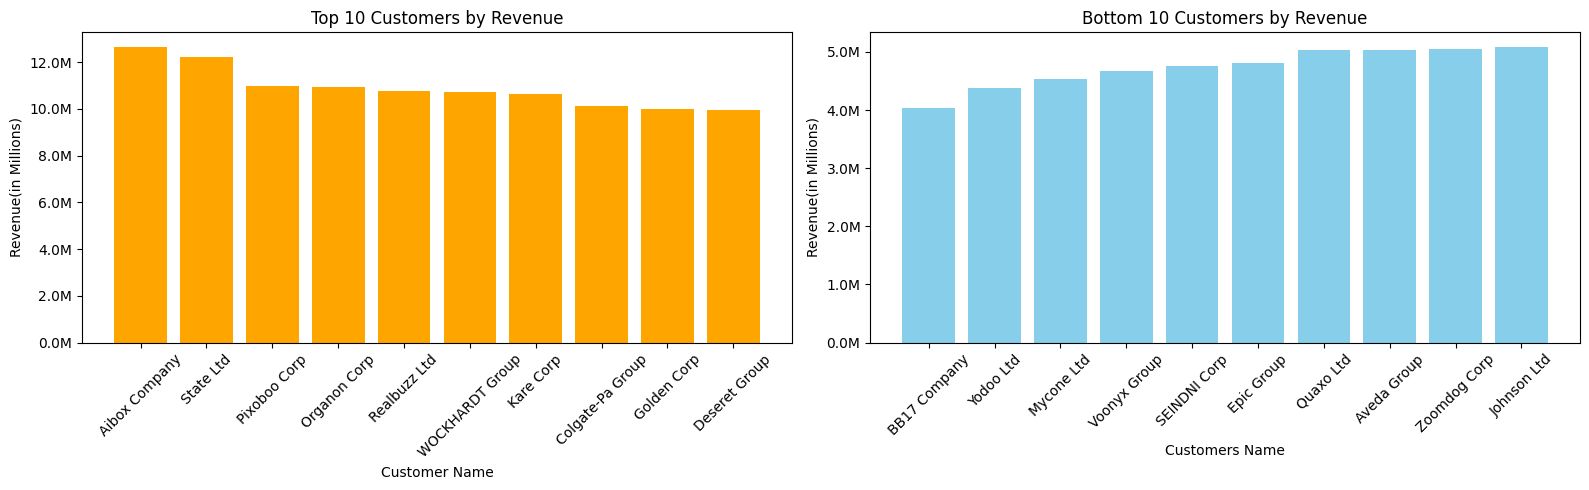

In [59]:
top_cus=df.groupby('customer_names')['revenue'].sum().reset_index().sort_values('revenue',ascending=False).head(10)

bottom_cus=df.groupby('customer_names')['revenue'].sum().reset_index().sort_values('revenue').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Chart 1 → Top Customers by Revenue
axes[0].bar(top_cus['customer_names'], top_cus['revenue'], color='orange')
axes[0].set_title('Top 10 Customers by Revenue')
axes[0].set_xlabel('Customer Name')
axes[0].set_ylabel('Revenue(in Millions)')

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
axes[0].yaxis.set_major_formatter(formatter)

axes[0].tick_params(axis='x', rotation=45)

# Chart 2 → Bottom Customers by Orders
axes[1].bar(bottom_cus['customer_names'], bottom_cus['revenue'], color='skyblue')
axes[1].set_title('Bottom 10 Customers by Revenue')
axes[1].set_xlabel('Customers Name')
axes[1].set_ylabel('Revenue(in Millions)')

axes[1].yaxis.set_major_formatter(formatter)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 11.Unit Price Distribution per Product

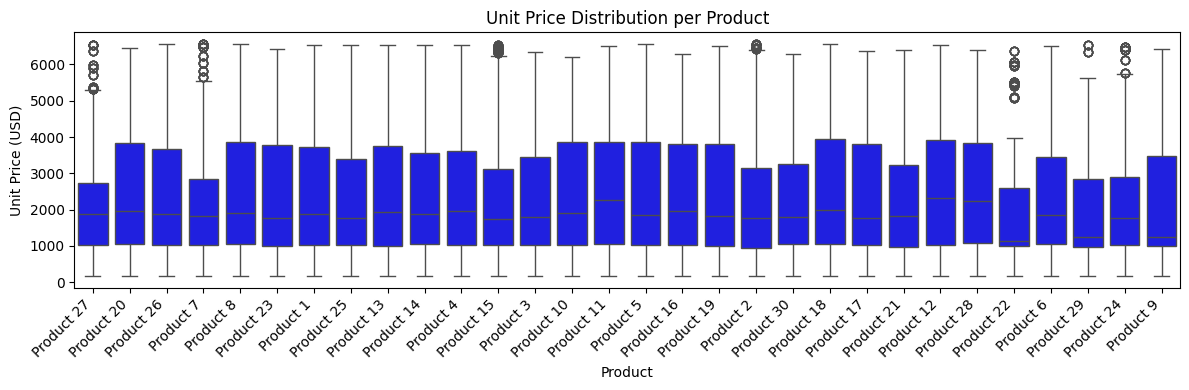

In [60]:
plt.figure(figsize=(12,4))

# Creat inga boxplot of unit_price by product_name
sns.boxplot(
    data=df,
    x='product_name',   # X-axis: product categories
    y='unit_price',      # Y-axis: unit price values
    color='b'            # Box color
)

plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')                              
plt.ylabel('Unit Price (USD)')                     

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
     

### 12. Correlation Heatmap of Numeric Features

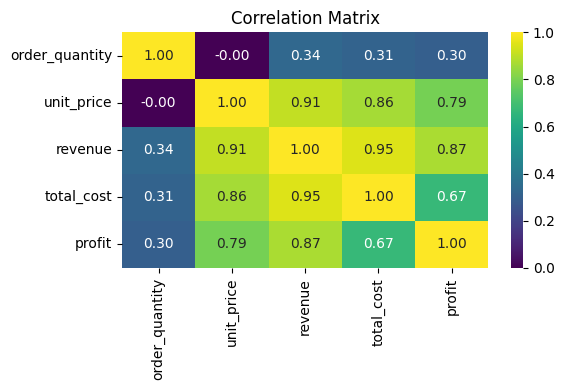

In [61]:
num_cols = ['order_quantity', 'unit_price', 'revenue', 'total_cost', 'profit']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for clarity
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,           # Data: correlation matrix
    annot=True,     # Display the correlation coefficients on the heatmap
    fmt=".2f",      # Format numbers to two decimal places
    cmap='viridis'  # Color palette for the heatmap
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
     

#### Insights

Profit and revenue are very strongly correlated (0.87), indicating that as sales value increases, profit tends to rise as well.

Unit price is a key driver: it correlates 0.91 with revenue, 0.79 with profit, and 0.86 with cost—highlighting how pricing decisions ripple through both top‑line and expense figures.

Cost shows a strong link to revenue (0.95) but a more moderate tie to profit (0.67), underscoring that while higher sales often bring higher expenses, margins can still vary.

Quantity has virtually no correlation with unit price (≈0.00) and only modest associations with revenue (0.34) and profit (0.30) and total cost (0.31), making volume a secondary factor compared to pricing.


In [62]:
# export final df to csv
df.to_csv('Regional_Sales(Pre-processesed data).csv',index=False)

In [63]:
#connecting nb to sql server
from sqlalchemy import create_engine
from urllib.parse import quote_plus

#note: require Microsoft ODBC driver installed seprately on your m/c

#define variables
driver=quote_plus("ODBC Driver 18 for SQL Server")
servername="LAPTOP-UNLO9CGR"
database="regional_sales"


engine=create_engine(
    f"mssql+pyodbc://@{servername}/{database}"
    f"?driver={driver}"
    f"&trusted_connection=yes&&TrustServerCertificate=yes"
)

In [64]:
#loading datafame into sql db
table_name="sales"
df.to_sql(table_name,engine,if_exists='replace',index=False)

print(f"Data successfully loaded into '{table_name} table'in database '{database}'.")

Data successfully loaded into 'sales table'in database 'regional_sales'.
